# KPI Development

## Objective

Develop business KPIs for the Quick Commerce War Room dashboard.

The KPIs are grouped into:

### Executive KPIs
- Total Revenue
- Total Orders
- Total Customers
- Average Order Value (AOV)
- Average Delivery Time

### Customer Intelligence KPIs
- Active Customers
- Repeat Customers
- Customer Segmentation

### Revenue Intelligence KPIs
- Revenue by City
- Revenue by Category
- Top Products

### Operations Intelligence KPIs
- Delivery Status Distribution
- Average Delivery Time
- Hub Performance
- Peak Ordering Hours

In [6]:
import pandas as pd
import numpy as np

In [7]:
dim_product = pd.read_csv("../data/processed/dim_product.csv")
dim_customer = pd.read_csv("../data/processed/dim_customer.csv")
dim_hub = pd.read_csv("../data/processed/dim_hub.csv")

fact_order_product = pd.read_csv("../data/processed/fact_order_product.csv")
fact_orders = pd.read_csv("../data/processed/fact_orders.csv")
fact_delivery = pd.read_csv("../data/processed/fact_delivery.csv")

In [8]:
print(dim_product.shape)
print(dim_customer.shape)
print(dim_hub.shape)
print(fact_order_product.shape)
print(fact_orders.shape)
print(fact_delivery.shape)

(49688, 7)
(206209, 5)
(24, 2)
(500000, 9)
(500000, 12)
(500000, 6)


## Executive KPI Calculation

These KPIs provide a high-level overview of business performance and are commonly displayed on executive dashboards.

The metrics focus on revenue, customer activity, order volume, and operational efficiency.

In [9]:
total_revenue = fact_orders["order_revenue"].sum()

print(f"Total Revenue: ₹{total_revenue:,.0f}")

Total Revenue: ₹1,096,075,391


In [10]:
total_orders = fact_orders["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 500,000


In [11]:
total_customers = fact_orders["user_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 160,057


In [12]:
aov = fact_orders["order_revenue"].mean()

print(f"Average Order Value: ₹{aov:.2f}")

Average Order Value: ₹2332.01


In [13]:
avg_delivery_time = fact_delivery["delivery_time_minutes"].mean()

print(f"Average Delivery Time: {avg_delivery_time:.2f} Minutes")

Average Delivery Time: 20.51 Minutes


In [14]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Delivery Time"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        round(aov, 2),
        round(avg_delivery_time, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,1.096075e+09
1,Total Orders,5.000000e+05
2,Total Customers,1.600570e+05
3,Average Order Value,2.332010e+03
4,Average Delivery Time,2.051000e+01


## Customer Intelligence KPIs

Analyze customer behavior, purchasing frequency, and customer segmentation to understand retention and customer value.

In [15]:
repeat_customers = (
    fact_orders.groupby("user_id")["order_id"]
    .count()
    .gt(1)
    .sum()
)

print(f"Repeat Customers: {repeat_customers:,}")

Repeat Customers: 105,166


In [16]:
repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print(
    f"Repeat Customer Rate: "
    f"{repeat_customer_rate:.2f}%"
)

Repeat Customer Rate: 65.71%


In [17]:
segment_distribution = (
    dim_customer["customer_segment"]
    .value_counts()
)

segment_distribution

customer_segment
Occasional    104513
Regular        72513
VIP            29183
Name: count, dtype: int64

In [18]:
segment_revenue = (
    fact_orders.groupby(
        "customer_segment"
    )["order_revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

segment_revenue

customer_segment
VIP           487040552.0
Regular       418245378.0
Occasional    190789461.0
Name: order_revenue, dtype: float64

In [19]:
segment_orders = (
    fact_orders.groupby(
        "customer_segment"
    )["order_id"]
    .count()
    .sort_values(
        ascending=False
    )
)

segment_orders

customer_segment
VIP           215839
Regular       187013
Occasional     97148
Name: order_id, dtype: int64

### Customer Intelligence Insights

Key metrics include:

- Repeat Customer Count
- Repeat Customer Rate
- Customer Segment Distribution
- Revenue Contribution by Segment
- Order Contribution by Segment

Key Findings:

- 65.7% of customers are repeat customers, indicating strong retention.
- VIP customers represent a relatively small portion of the customer base but contribute the largest share of revenue.
- VIP customers generate the highest order volume and overall business value.
- Customer revenue is concentrated among loyal and high-frequency buyers.

## Revenue Intelligence KPIs

Analyze revenue distribution across cities, products, and customer groups to identify growth opportunities and top-performing business areas.

In [20]:
revenue_by_city = (
    fact_orders.groupby("city")["order_revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_city

city
Mumbai       138488871.0
Pune         138121775.0
Delhi        137724474.0
Chennai      136993461.0
Kolkata      136688559.0
Hyderabad    136512429.0
Gurugram     135849400.0
Bangalore    135696422.0
Name: order_revenue, dtype: float64

In [21]:
orders_by_city = (
    fact_orders.groupby("city")["order_id"]
    .count()
    .sort_values(ascending=False)
)

orders_by_city

city
Mumbai       63189
Pune         63137
Hyderabad    62871
Delhi        62685
Bangalore    62198
Kolkata      62117
Chennai      61953
Gurugram     61850
Name: order_id, dtype: int64

In [22]:
aov_by_city = (
    fact_orders.groupby("city")["order_revenue"]
    .mean()
    .sort_values(ascending=False)
)

aov_by_city

city
Chennai      2352.869281
Kolkata      2343.527055
Gurugram     2336.711561
Delhi        2335.777929
Mumbai       2330.991567
Pune         2328.967980
Bangalore    2315.836198
Hyderabad    2311.810821
Name: order_revenue, dtype: float64

In [23]:
top_10_cities = revenue_by_city.head(10)

top_10_cities

city
Mumbai       138488871.0
Pune         138121775.0
Delhi        137724474.0
Chennai      136993461.0
Kolkata      136688559.0
Hyderabad    136512429.0
Gurugram     135849400.0
Bangalore    135696422.0
Name: order_revenue, dtype: float64

### Revenue Intelligence Insights

Key Findings:

- Mumbai generated the highest revenue among all cities.
- Revenue distribution is highly balanced across operating regions.
- Order volume remains consistent across all cities, indicating stable demand.
- Chennai recorded the highest Average Order Value (AOV).
- No single city dominates revenue generation, reducing geographic concentration risk.

## Operations Intelligence KPIs

Analyze delivery performance, operational efficiency, and fulfillment hub effectiveness to monitor service quality and identify operational bottlenecks.

In [24]:
delivery_status = (
    fact_delivery["delivery_status"]
    .value_counts()
)

delivery_status

delivery_status
Delivered     374735
Delayed       100103
High Delay     25162
Name: count, dtype: int64

In [25]:
delivery_status_pct = (
    fact_delivery["delivery_status"]
    .value_counts(normalize=True)
    * 100
)

delivery_status_pct

delivery_status
Delivered     74.9470
Delayed       20.0206
High Delay     5.0324
Name: proportion, dtype: float64

In [26]:
delivery_time_city = (
    fact_delivery.groupby("city")
    ["delivery_time_minutes"]
    .mean()
    .sort_values()
)

delivery_time_city

city
Gurugram     20.411382
Chennai      20.466515
Pune         20.468299
Hyderabad    20.503412
Delhi        20.521257
Kolkata      20.524381
Mumbai       20.563674
Bangalore    20.624827
Name: delivery_time_minutes, dtype: float64

In [27]:
hub_orders = (
    fact_orders.groupby("hub_id")
    ["order_id"]
    .count()
    .sort_values(
        ascending=False
    )
)

hub_orders

hub_id
PUN_01    21554
MUM_02    21501
DEL_02    21368
DEL_01    21217
HYD_02    21155
KOL_02    21029
BLR_03    20977
HYD_01    20968
BLR_01    20935
MUM_01    20906
CHE_01    20849
PUN_03    20825
MUM_03    20782
PUN_02    20758
HYD_03    20748
GUR_02    20710
KOL_01    20628
GUR_01    20589
CHE_02    20557
GUR_03    20551
CHE_03    20547
KOL_03    20460
BLR_02    20286
DEL_03    20100
Name: order_id, dtype: int64

In [28]:
hub_revenue = (
    fact_orders.groupby("hub_id")
    ["order_revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

hub_revenue

hub_id
DEL_01    47428214.0
MUM_02    47297173.0
PUN_01    47204572.0
CHE_01    46436844.0
KOL_02    46302468.0
HYD_01    46200559.0
BLR_01    46006689.0
MUM_01    45887828.0
KOL_01    45874888.0
PUN_03    45719378.0
DEL_02    45556422.0
HYD_02    45399368.0
GUR_02    45339610.0
MUM_03    45303870.0
CHE_03    45283363.0
CHE_02    45273254.0
GUR_03    45259607.0
GUR_01    45250183.0
PUN_02    45197825.0
BLR_03    45166428.0
HYD_03    44912502.0
DEL_03    44739838.0
BLR_02    44523305.0
KOL_03    44511203.0
Name: order_revenue, dtype: float64

In [29]:
peak_hours = (
    fact_orders.groupby(
        "order_hour_of_day"
    )["order_id"]
    .count()
    .sort_values(
        ascending=False
    )
)

peak_hours

order_hour_of_day
10    42336
11    41605
15    41511
14    41219
13    41010
12    39742
16    39648
9     37615
17    33611
18    26699
8     26064
19    20458
20    15234
7     13339
21    11338
22     9006
23     5802
6      4497
0      3305
1      1861
5      1437
2      1087
4       798
3       778
Name: order_id, dtype: int64

### Operations Intelligence Insights

Key Findings:

- Approximately 75% of orders are delivered within the expected delivery window.
- Delivery performance is highly consistent across all cities.
- Revenue contribution is evenly distributed across fulfillment hubs.
- Peak demand occurs between 10 AM and 4 PM.
- Operational resources should be concentrated during high-demand periods to maintain service quality.

### Revenue by City

Analyze revenue contribution across operating cities to identify top-performing markets.

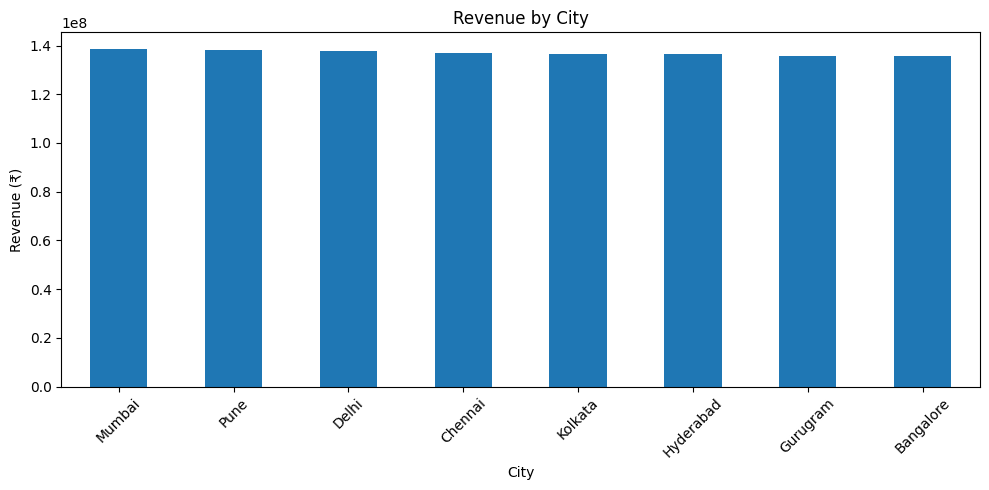

In [30]:
import matplotlib.pyplot as plt

revenue_by_city.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

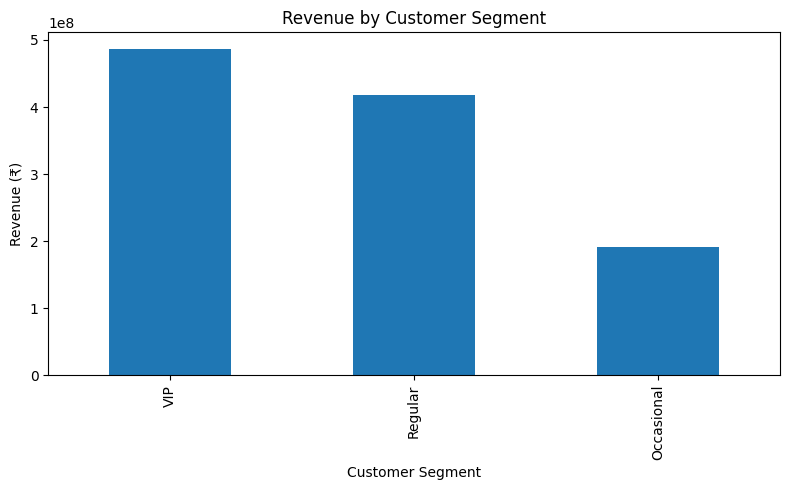

In [31]:
segment_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

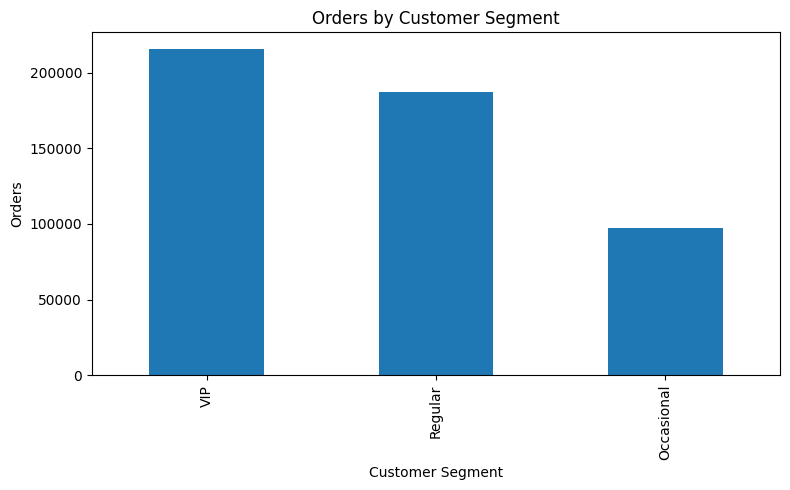

In [32]:
segment_orders.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Orders")

plt.tight_layout()
plt.show()

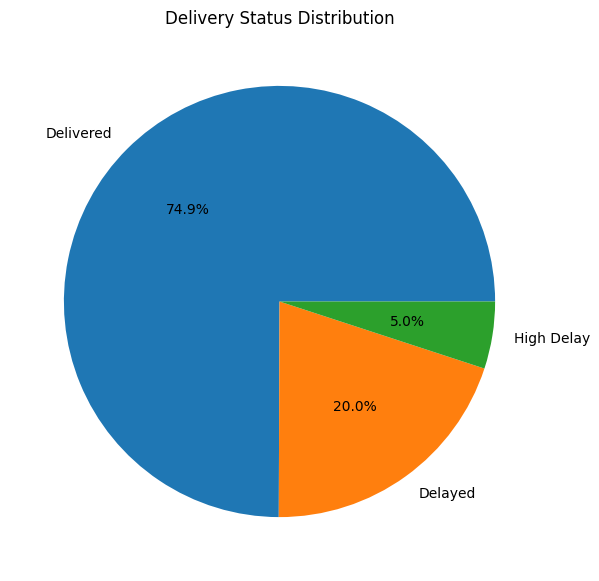

In [33]:
delivery_status.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Delivery Status Distribution")
plt.ylabel("")

plt.show()

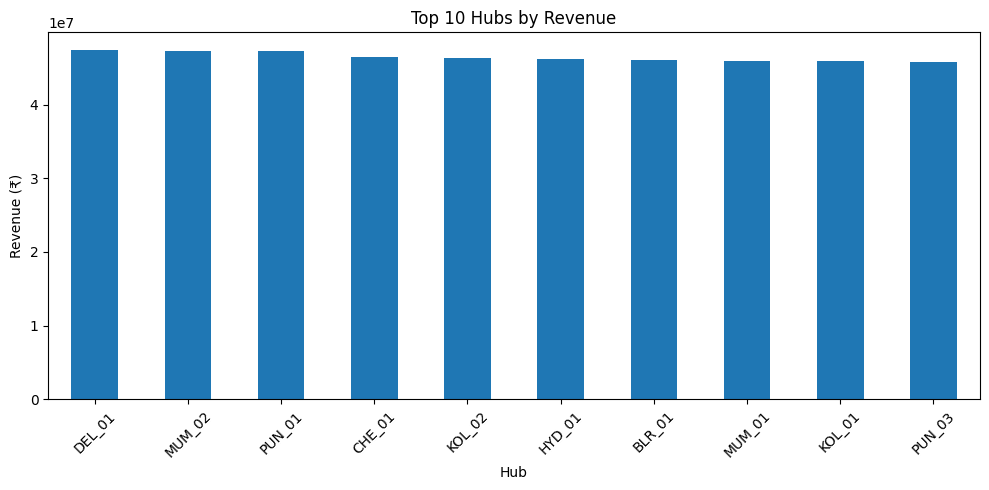

In [34]:
hub_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Hubs by Revenue")
plt.xlabel("Hub")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

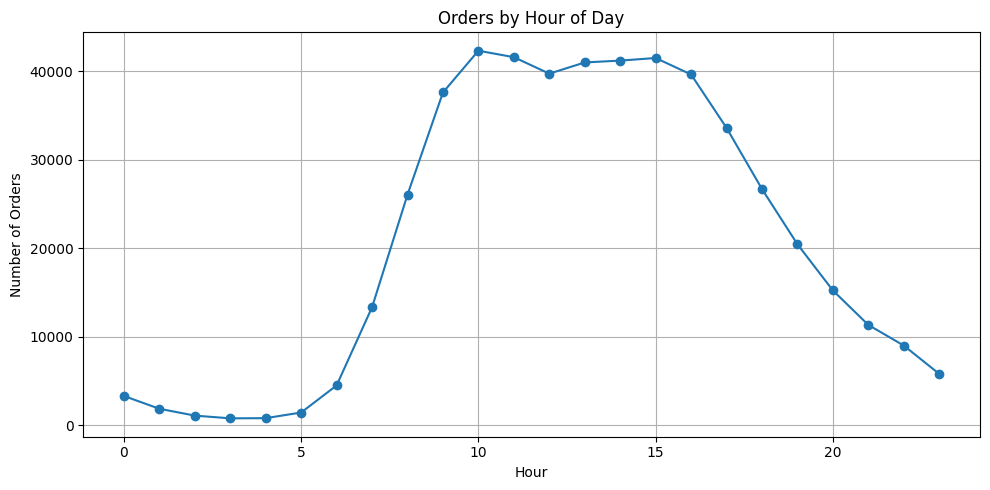

In [35]:
peak_hours.sort_index().plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
customer_orders = (
    fact_orders
    .groupby("user_id")["order_id"]
    .count()
)

(customer_orders > 1).mean() * 100

np.float64(65.70534247174444)

In [49]:
crr = fact_orders.groupby("user_id")["order_id"].count()


user_id
2         0.000008
3         0.000006
6         0.000004
7         0.000008
9         0.000002
            ...   
206202    0.000014
206206    0.000020
206207    0.000006
206208    0.000012
206209    0.000006
Name: order_id, Length: 160057, dtype: float64